In [ ]:
# Credit Card Fraud Detection - Baseline EDA & Understanding\n\n**Dataset**: Credit card transactions by European cardholders (September 2013)  \n**Goal**: Understand data characteristics before building fraud detection models  \n**Key Challenge**: Highly imbalanced dataset (0.172% frauds)

hello world


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

In [7]:
## 1. Load Data

In [8]:
df = pd.read_csv("../data/creditcard.csv")
print(f"Dataset loaded: {df.shape[0]:,} transactions, {df.shape[1]} features")
df.head()

Dataset loaded: 284,807 transactions, 31 features


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
## 2. Basic Dataset Information

In [10]:
# Dataset shape, types, memory usage, missing values
print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nFeatures: {list(df.columns)}")

DATASET OVERVIEW

Shape: 284,807 rows × 31 columns
Memory usage: 70.6 MB

Missing values: 0
Duplicate rows: 1081

Data types:
float64    30
int64       1
Name: count, dtype: int64

Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [11]:
# Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 3. Class Distribution (Target Variable Analysis)\n\nThe dataset is known to be highly imbalanced. Let's quantify this.

CLASS DISTRIBUTION
----------------------------------------
Legitimate (0): 284,315 (99.827%)
Fraudulent (1): 492 (0.173%)

Imbalance ratio: 1:577


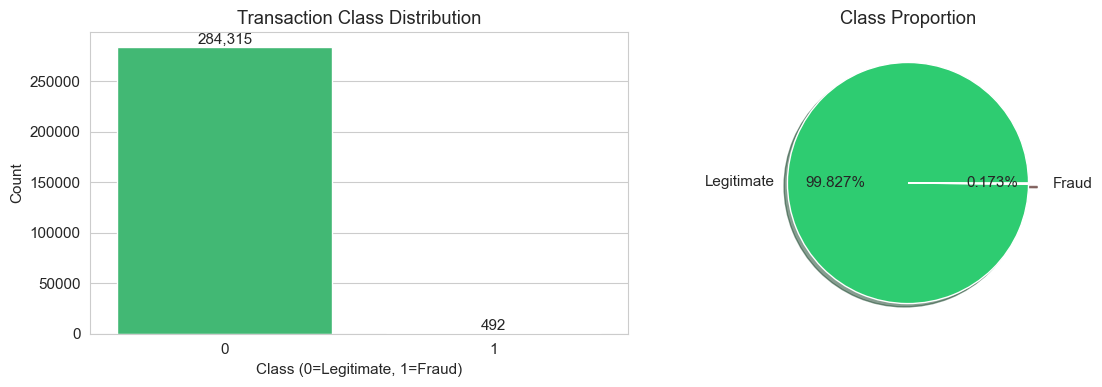

In [12]:
# Class distribution
fraud_counts = df['Class'].value_counts()
fraud_pct = df['Class'].value_counts(normalize=True) * 100

print("CLASS DISTRIBUTION")
print("-"*40)
print(f"Legitimate (0): {fraud_counts[0]:,} ({fraud_pct[0]:.3f}%)")
print(f"Fraudulent (1): {fraud_counts[1]:,} ({fraud_pct[1]:.3f}%)")
print(f"\nImbalance ratio: 1:{fraud_counts[0]//fraud_counts[1]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title("Transaction Class Distribution")
axes[0].set_xlabel("Class (0=Legitimate, 1=Fraud)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'], 
            autopct='%1.3f%%', colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.1), shadow=True)
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()

## 4. Feature Analysis: Time and Amount\n\nThese are the only non-PCA transformed features. Let's understand their distributions for fraud vs legitimate.

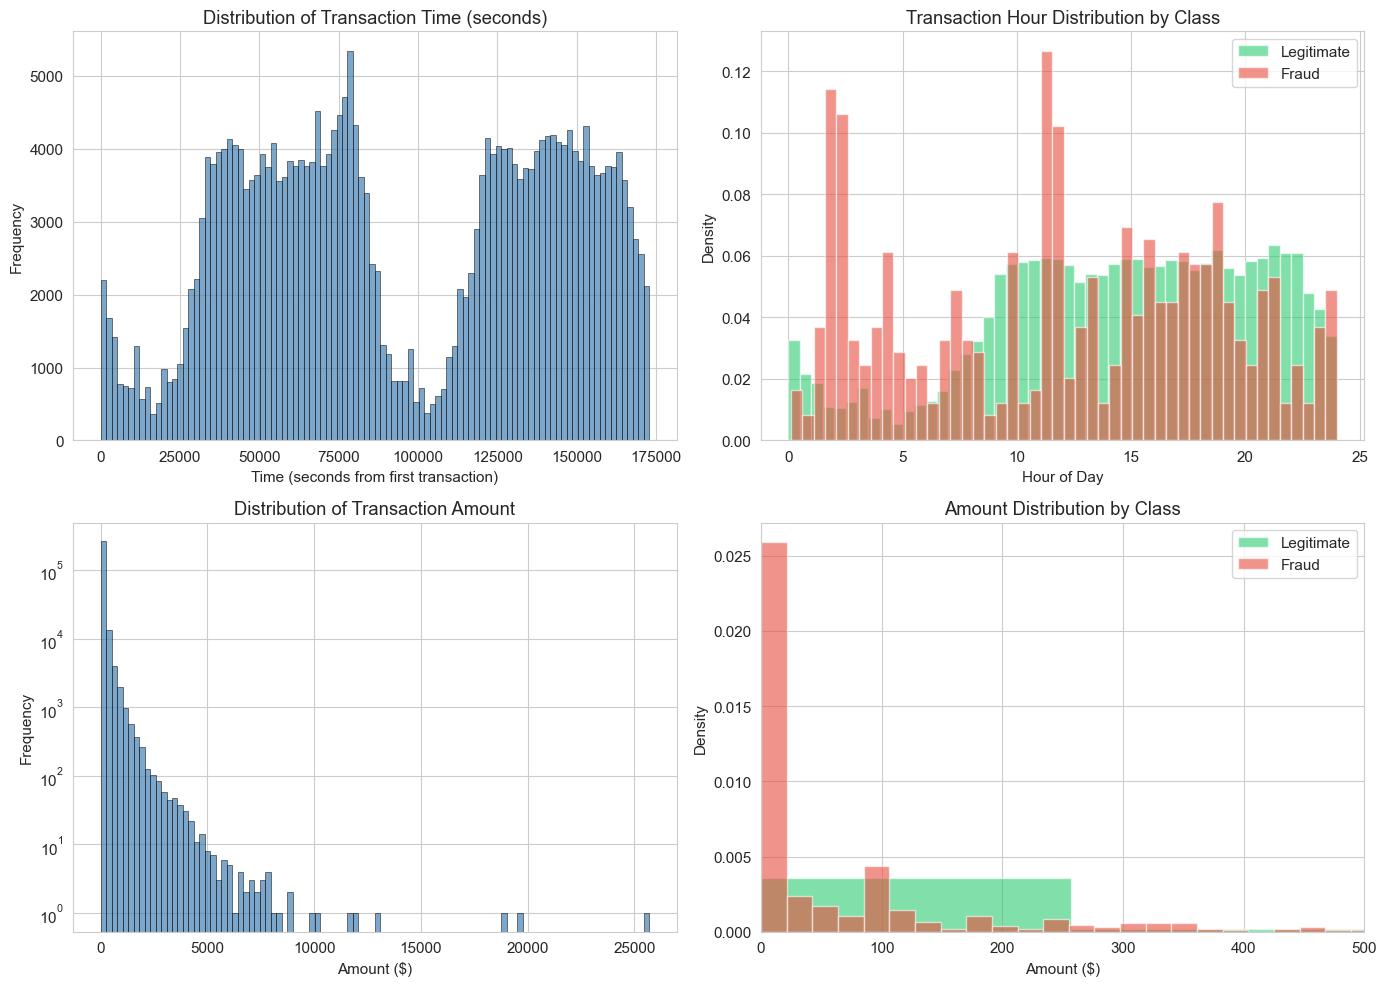


AMOUNT STATISTICS BY CLASS
--------------------------------------------------
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [13]:
# Time feature analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time distribution - overall
axes[0, 0].hist(df['Time'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0, 0].set_title("Distribution of Transaction Time (seconds)")
axes[0, 0].set_xlabel("Time (seconds from first transaction)")
axes[0, 0].set_ylabel("Frequency")

# Time in hours for better interpretation
df['Hour'] = df['Time'].apply(lambda x: (x / 3600) % 24)

# Time distribution by class
axes[0, 1].hist(df[df['Class']==0]['Hour'], bins=48, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
axes[0, 1].hist(df[df['Class']==1]['Hour'], bins=48, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
axes[0, 1].set_title("Transaction Hour Distribution by Class")
axes[0, 1].set_xlabel("Hour of Day")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# Amount distribution - overall (log scale)
axes[1, 0].hist(df['Amount'], bins=100, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title("Distribution of Transaction Amount")
axes[1, 0].set_xlabel("Amount ($)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_yscale('log')

# Amount by class
axes[1, 1].hist(df[df['Class']==0]['Amount'], bins=100, alpha=0.6, label='Legitimate', color='#2ecc71', density=True)
axes[1, 1].hist(df[df['Class']==1]['Amount'], bins=100, alpha=0.6, label='Fraud', color='#e74c3c', density=True)
axes[1, 1].set_title("Amount Distribution by Class")
axes[1, 1].set_xlabel("Amount ($)")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

# Summary statistics for Amount by class
print("\nAMOUNT STATISTICS BY CLASS")
print("-"*50)
print(df.groupby('Class')['Amount'].describe())

## 5. PCA Feature Distributions (V1–V28)\n\nAll V features are PCA-transformed. Let's compare their distributions between fraud and legitimate transactions.

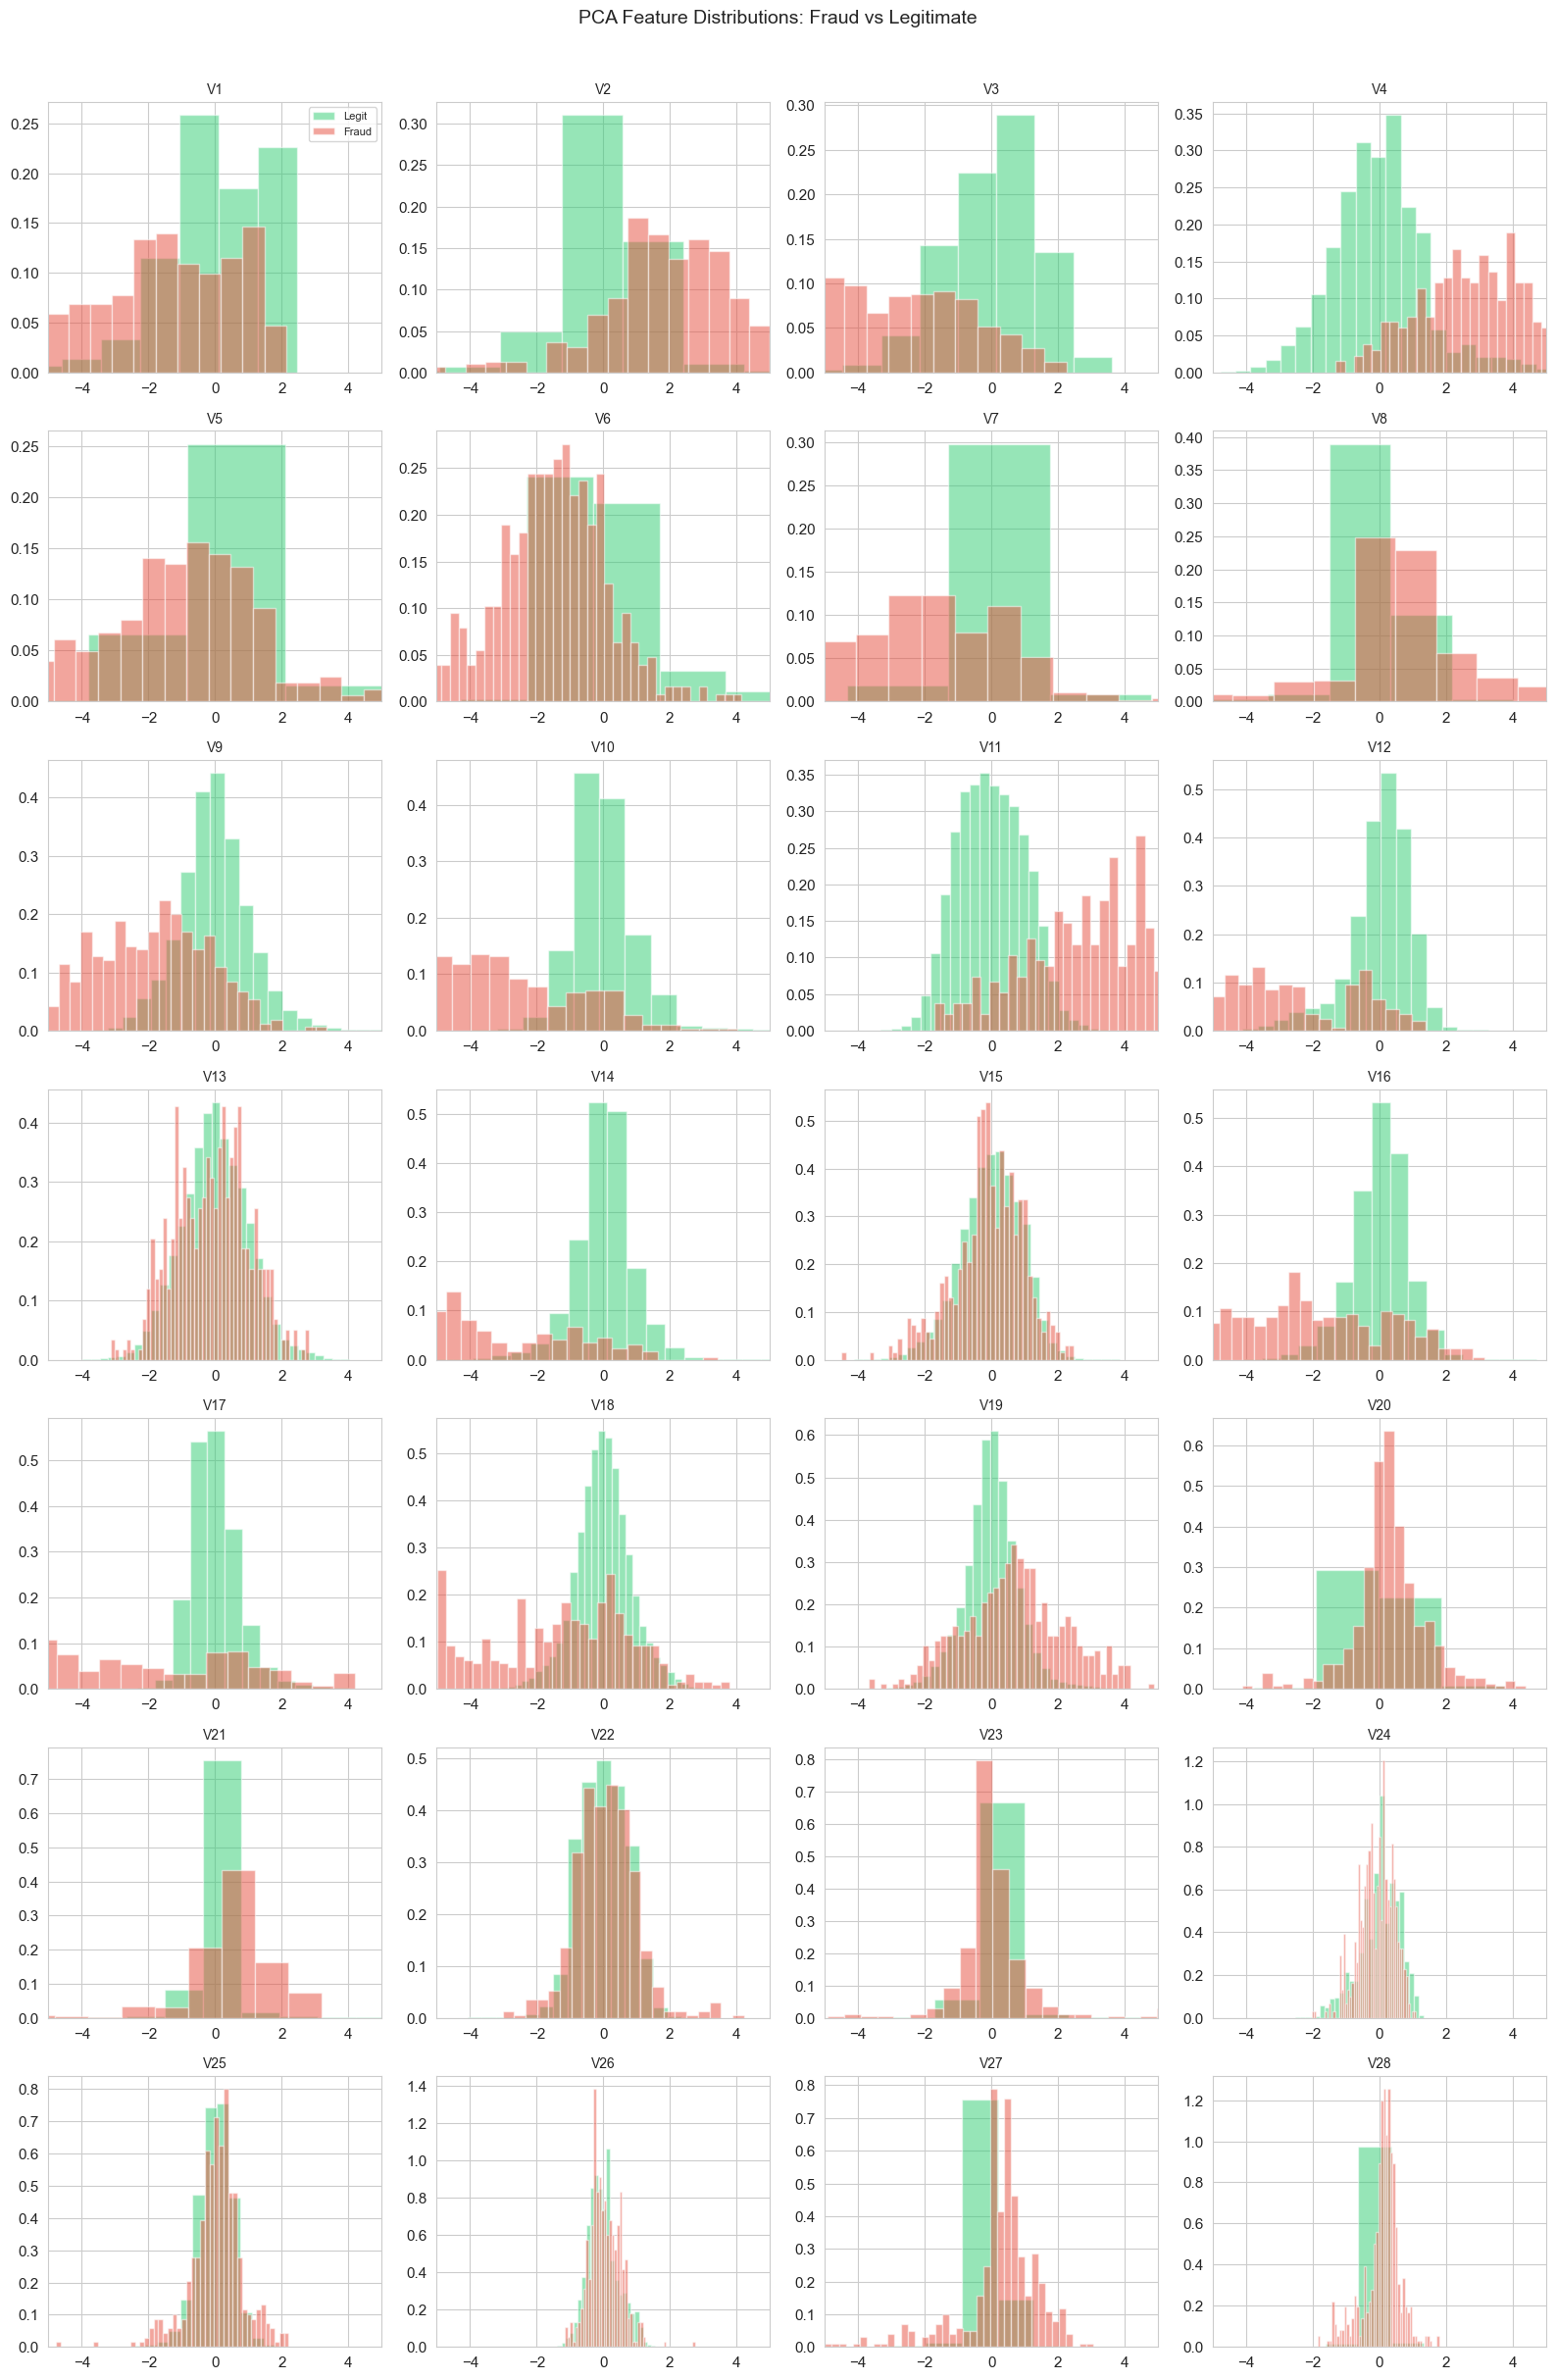

In [20]:
# Distribution of PCA features: Fraud vs Legitimate
v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(16, 24))
axes = axes.flatten()

for i, feat in enumerate(v_features):
    ax = axes[i]
    ax.hist(df[df['Class']==0][feat], bins=50, alpha=0.5, label='Legit', color='#2ecc71', density=True)
    ax.hist(df[df['Class']==1][feat], bins=50, alpha=0.5, label='Fraud', color='#e74c3c', density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_xlim(-5, 5)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle("PCA Feature Distributions: Fraud vs Legitimate", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Identify features with most separation between classes (using KS statistic)
ks_results = []
for feat in v_features + ['Amount', 'Time']:
    stat, pval = stats.ks_2samp(
        df[df['Class']==0][feat].values,
        df[df['Class']==1][feat].values
    )
    ks_results.append({'Feature': feat, 'KS_Statistic': stat, 'P_Value': pval})

ks_df = pd.DataFrame(ks_results).sort_values('KS_Statistic', ascending=False)
print("TOP FEATURES BY CLASS SEPARATION (Kolmogorov-Smirnov Test)")
print("="*60)
print("Higher KS statistic = more separation between fraud & legitimate")
print()
print(ks_df.head(15).to_string(index=False))

TOP FEATURES BY CLASS SEPARATION (Kolmogorov-Smirnov Test)
Higher KS statistic = more separation between fraud & legitimate

Feature  KS_Statistic       P_Value
    V14      0.842839  0.000000e+00
    V10      0.804291  0.000000e+00
    V12      0.783908 8.606624e-321
     V4      0.766404 2.040642e-302
    V11      0.756067 4.347507e-292
    V17      0.745173 1.387411e-281
     V3      0.703682 9.927580e-245
    V16      0.686506 9.366543e-231
     V7      0.660578 6.776862e-211
     V2      0.633201 2.163895e-191
     V9      0.576320 4.388938e-155
    V21      0.518527 2.891360e-123
    V18      0.503360 1.129800e-115
     V6      0.486425 1.517254e-107
     V1      0.475331 2.048461e-102


## 6. Correlation Analysis

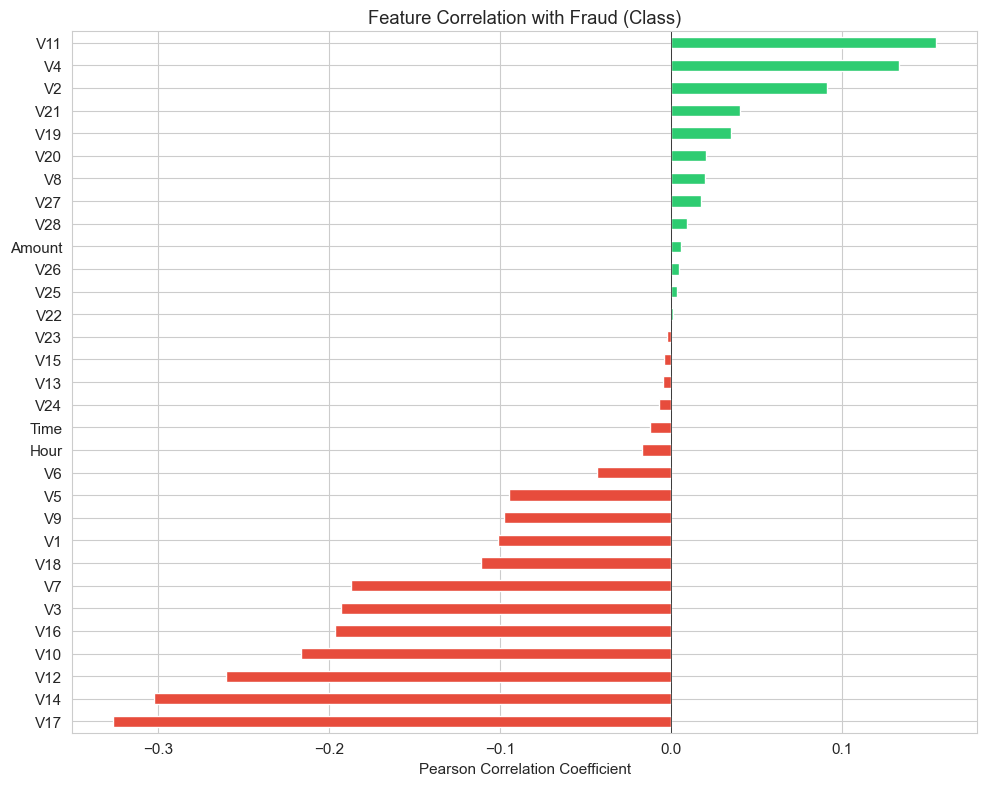


Top positive correlations (associated with fraud):
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

Top negative correlations (associated with fraud):
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [22]:
# Correlation with target variable
correlations = df.corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Feature Correlation with Fraud (Class)")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop positive correlations (associated with fraud):")
print(correlations.tail(5))
print("\nTop negative correlations (associated with fraud):")
print(correlations.head(5))

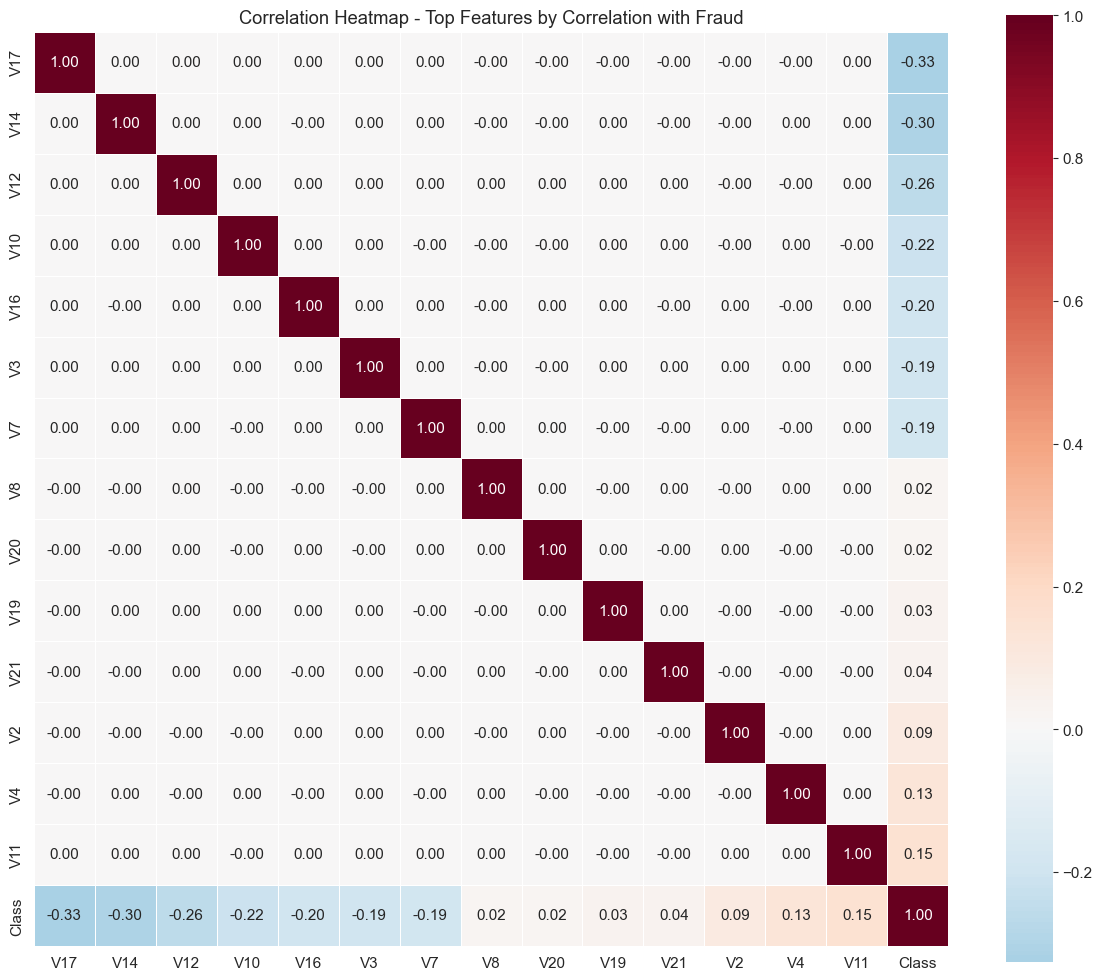

In [23]:
# Heatmap of feature correlations (subset of top features)
top_features = list(correlations.head(7).index) + list(correlations.tail(7).index) + ['Class']
corr_matrix = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title("Correlation Heatmap - Top Features by Correlation with Fraud")
plt.tight_layout()
plt.show()

## 7. Detailed Fraud vs Legitimate Comparison\n\nBoxplots of top discriminating features to understand how fraud transactions differ.

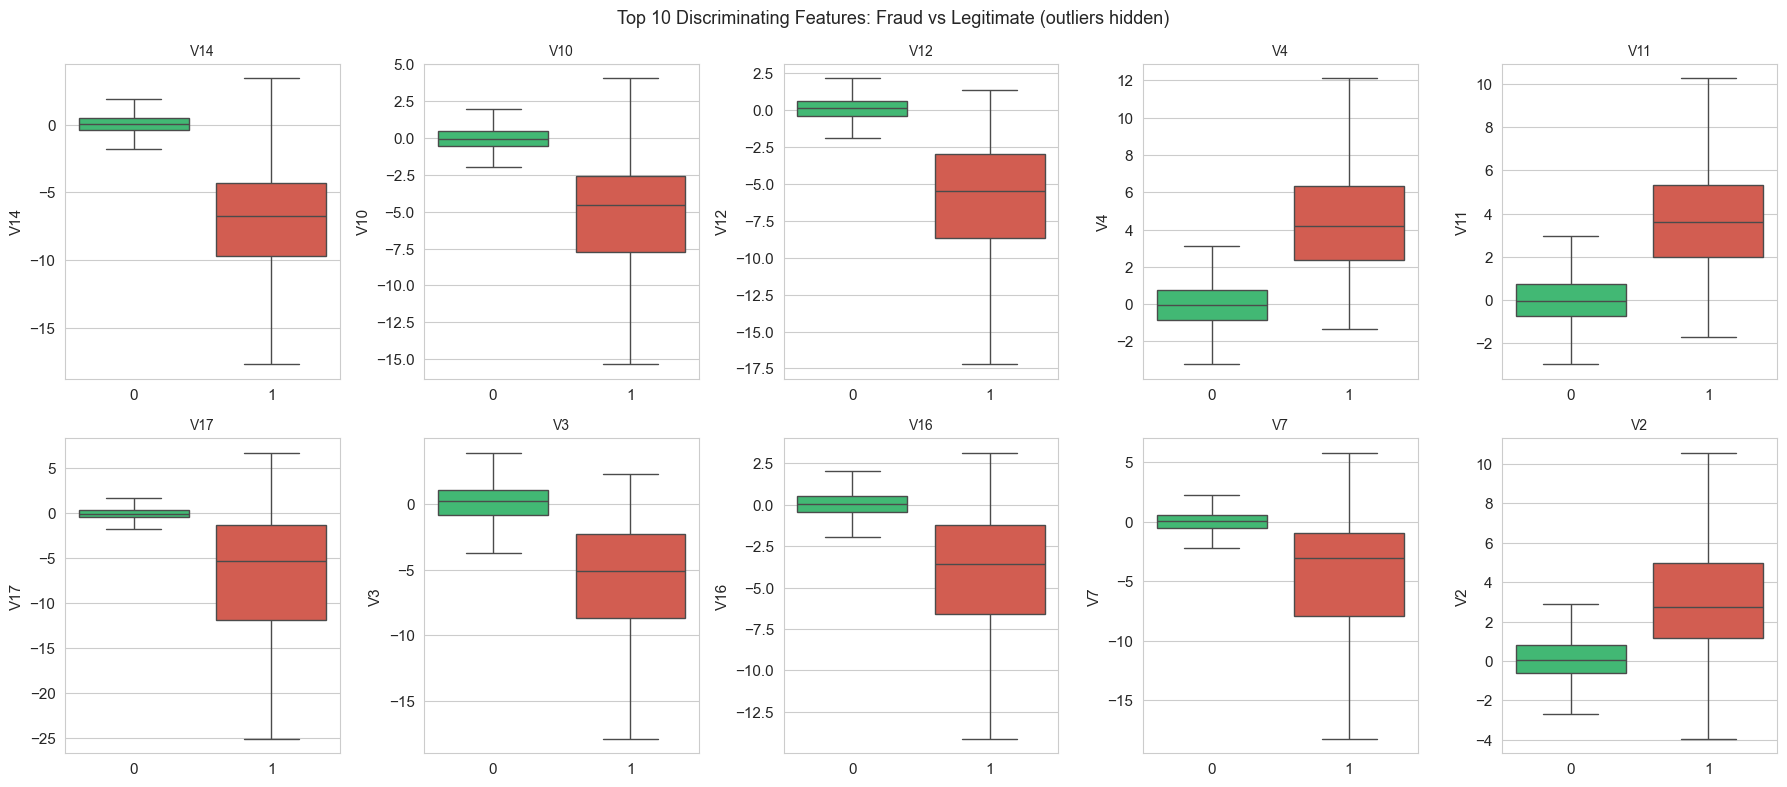

In [24]:
# Boxplots for top discriminating features
top_disc_features = list(ks_df.head(10)['Feature'].values)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top_disc_features):
    sns.boxplot(x='Class', y=feat, data=df, ax=axes[i], 
                palette=['#2ecc71', '#e74c3c'], showfliers=False)
    axes[i].set_title(f'{feat}', fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle("Top 10 Discriminating Features: Fraud vs Legitimate (outliers hidden)", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# Transaction amount analysis - Fraud vs Legitimate
print("TRANSACTION AMOUNT ANALYSIS")
print("="*60)
print(f"\nLegitimate transactions:")
print(f"  Mean: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"  Median: ${df[df['Class']==0]['Amount'].median():.2f}")
print(f"  Max: ${df[df['Class']==0]['Amount'].max():.2f}")
print(f"  Std: ${df[df['Class']==0]['Amount'].std():.2f}")

print(f"\nFraudulent transactions:")
print(f"  Mean: ${df[df['Class']==1]['Amount'].mean():.2f}")
print(f"  Median: ${df[df['Class']==1]['Amount'].median():.2f}")
print(f"  Max: ${df[df['Class']==1]['Amount'].max():.2f}")
print(f"  Std: ${df[df['Class']==1]['Amount'].std():.2f}")

# Statistical test
stat, pval = stats.mannwhitneyu(
    df[df['Class']==0]['Amount'].values,
    df[df['Class']==1]['Amount'].values
)
print(f"\nMann-Whitney U test (Amount): statistic={stat:.2f}, p-value={pval:.2e}")
print("=> Significant difference" if pval < 0.05 else "=> No significant difference")

TRANSACTION AMOUNT ANALYSIS

Legitimate transactions:
  Mean: $88.29
  Median: $22.00
  Max: $25691.16
  Std: $250.11

Fraudulent transactions:
  Mean: $122.21
  Median: $9.25
  Max: $2125.87
  Std: $256.68

Mann-Whitney U test (Amount): statistic=78049581.00, p-value=8.58e-06
=> Significant difference


## 8. Temporal Patterns

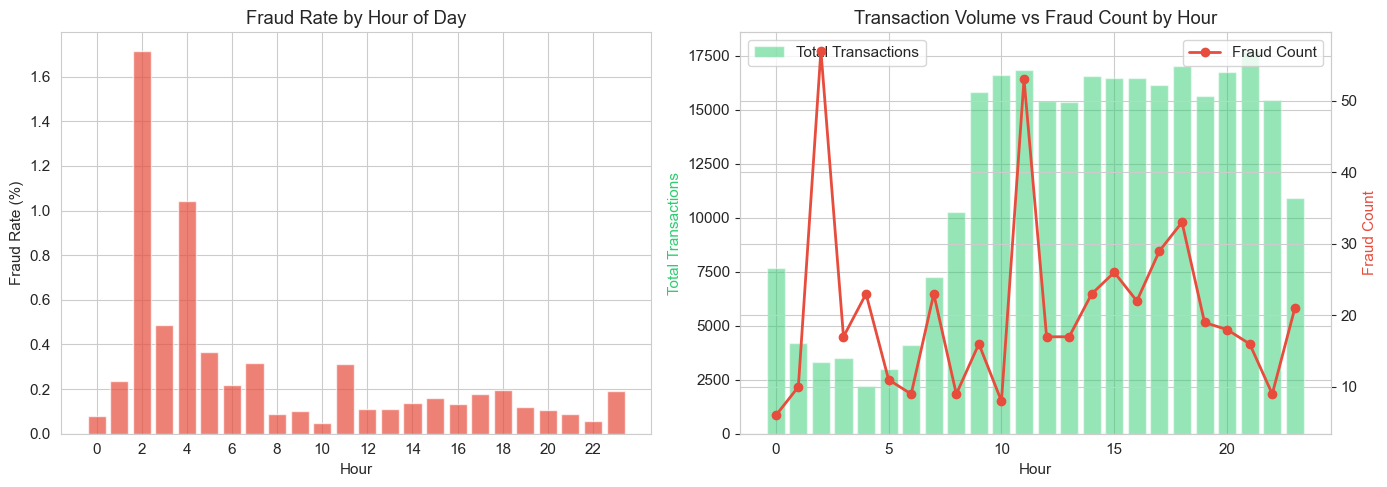


Key Insight: Frauds tend to have higher rates during low-activity hours (night time)
This makes sense - fraudsters operate when cardholders are less likely to notice.


In [26]:
# Temporal patterns - when do frauds happen?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
hourly_fraud = df.groupby(df['Hour'].astype(int)).agg(
    total=('Class', 'count'),
    frauds=('Class', 'sum')
)
hourly_fraud['fraud_rate'] = hourly_fraud['frauds'] / hourly_fraud['total'] * 100

axes[0].bar(hourly_fraud.index, hourly_fraud['fraud_rate'], color='#e74c3c', alpha=0.7)
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Fraud Rate (%)")
axes[0].set_xticks(range(0, 24, 2))

# Transaction volume vs fraud volume by hour
ax2 = axes[1]
ax2.bar(hourly_fraud.index, hourly_fraud['total'], color='#2ecc71', alpha=0.5, label='Total Transactions')
ax2_twin = ax2.twinx()
ax2_twin.plot(hourly_fraud.index, hourly_fraud['frauds'], color='#e74c3c', linewidth=2, marker='o', label='Fraud Count')
ax2.set_title("Transaction Volume vs Fraud Count by Hour")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Total Transactions", color='#2ecc71')
ax2_twin.set_ylabel("Fraud Count", color='#e74c3c')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nKey Insight: Frauds tend to have higher rates during low-activity hours (night time)")
print("This makes sense - fraudsters operate when cardholders are less likely to notice.")

## 9. Outlier Analysis & Data Quality Summary

In [27]:
# Outlier detection using IQR method for Amount
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]
print("OUTLIER ANALYSIS (Amount feature - IQR method)")
print("="*60)
print(f"Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"Lower bound: ${lower_bound:.2f}, Upper bound: ${upper_bound:.2f}")
print(f"Number of outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")
print(f"Fraud rate in outliers: {outliers['Class'].mean()*100:.2f}%")
print(f"Fraud rate in non-outliers: {df[~df.index.isin(outliers.index)]['Class'].mean()*100:.2f}%")

OUTLIER ANALYSIS (Amount feature - IQR method)
Q1: $5.60, Q3: $77.16, IQR: $71.56
Lower bound: $-101.75, Upper bound: $184.51
Number of outliers: 31,904 (11.20%)
Fraud rate in outliers: 0.29%
Fraud rate in non-outliers: 0.16%


## 10. Key Findings & Summary\n\nSummary of EDA insights that will inform model building.

In [28]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║              KEY FINDINGS FROM EDA                               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. EXTREME CLASS IMBALANCE                                      ║
║     - Only ~0.17% transactions are fraudulent                    ║
║     - Need: SMOTE, undersampling, or cost-sensitive learning     ║
║     - Metric: Use AUPRC, not accuracy                            ║
║                                                                  ║
║  2. NO MISSING VALUES                                            ║
║     - Clean dataset, no imputation needed                        ║
║                                                                  ║
║  3. FEATURE SCALING NEEDED                                       ║
║     - Amount has very different scale than V features             ║
║     - Time needs normalization                                   ║
║                                                                  ║
║  4. DISCRIMINATING FEATURES EXIST                                ║
║     - V14, V12, V10 show strong negative correlation with fraud  ║
║     - V4, V11 show positive correlation                          ║
║     - KS test confirms significant distributional differences    ║
║                                                                  ║
║  5. TEMPORAL PATTERNS                                            ║
║     - Higher fraud rate during nighttime (low-activity hours)    ║
║     - Suggests time-based features could be valuable             ║
║                                                                  ║
║  6. AMOUNT PATTERNS                                              ║
║     - Fraud transactions tend to have different amount profile   ║
║     - Amount outliers have different fraud rates                  ║
║                                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  NEXT STEPS:                                                     ║
║  - Scale Amount and Time features                                ║
║  - Handle class imbalance (SMOTE/undersampling)                  ║
║  - Build baseline model (Logistic Regression)                    ║
║  - Evaluate with AUPRC, Precision-Recall, F1                    ║
║  - Try ensemble methods (Random Forest, XGBoost)                 ║
╚══════════════════════════════════════════════════════════════════╝
""")

# Clean up helper column
df.drop('Hour', axis=1, inplace=True, errors='ignore')


╔══════════════════════════════════════════════════════════════════╗
║              KEY FINDINGS FROM EDA                               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. EXTREME CLASS IMBALANCE                                      ║
║     - Only ~0.17% transactions are fraudulent                    ║
║     - Need: SMOTE, undersampling, or cost-sensitive learning     ║
║     - Metric: Use AUPRC, not accuracy                            ║
║                                                                  ║
║  2. NO MISSING VALUES                                            ║
║     - Clean dataset, no imputation needed                        ║
║                                                                  ║
║  3. FEATURE SCALING NEEDED                                       ║
║     - Amount has very different scale than V features             ║
║     - Time needs normalization

## 11. Save Artifacts

Save all EDA artifacts (processed data, statistics, feature importance rankings) for downstream use.

In [ ]:
import os
import json
import pickle

# Create artifacts directory
artifacts_dir = os.path.join(os.path.dirname(os.getcwd()), "notebooks", "notebook_artifacts")
os.makedirs(artifacts_dir, exist_ok=True)

# --- 1. Save processed dataset (with Hour feature for downstream use) ---
df['Hour'] = df['Time'].apply(lambda x: (x / 3600) % 24)
df.to_parquet(os.path.join(artifacts_dir, "creditcard_processed.parquet"), index=False)
df.drop('Hour', axis=1, inplace=True, errors='ignore')

# --- 2. Save KS Test results (feature discrimination ranking) ---
ks_results = []
v_features = [f'V{i}' for i in range(1, 29)]
for feat in v_features + ['Amount', 'Time']:
    stat, pval = stats.ks_2samp(
        df[df['Class']==0][feat].values,
        df[df['Class']==1][feat].values
    )
    ks_results.append({'Feature': feat, 'KS_Statistic': stat, 'P_Value': pval})

ks_df = pd.DataFrame(ks_results).sort_values('KS_Statistic', ascending=False).reset_index(drop=True)
ks_df.to_csv(os.path.join(artifacts_dir, "feature_ks_statistics.csv"), index=False)

# --- 3. Save correlation with target ---
correlations = df.corr()['Class'].drop('Class').sort_values()
correlations.to_csv(os.path.join(artifacts_dir, "feature_correlations_with_target.csv"), header=True)

# --- 4. Save class distribution summary ---
class_summary = {
    "total_transactions": int(df.shape[0]),
    "total_features": int(df.shape[1]),
    "legitimate_count": int((df['Class'] == 0).sum()),
    "fraud_count": int((df['Class'] == 1).sum()),
    "fraud_percentage": float(df['Class'].mean() * 100),
    "imbalance_ratio": f"1:{(df['Class']==0).sum() // (df['Class']==1).sum()}",
    "amount_stats": {
        "legitimate_mean": float(df[df['Class']==0]['Amount'].mean()),
        "legitimate_median": float(df[df['Class']==0]['Amount'].median()),
        "fraud_mean": float(df[df['Class']==1]['Amount'].mean()),
        "fraud_median": float(df[df['Class']==1]['Amount'].median()),
    },
    "top_discriminating_features": list(ks_df.head(10)['Feature'].values),
    "missing_values": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
}

with open(os.path.join(artifacts_dir, "eda_summary.json"), "w") as f:
    json.dump(class_summary, f, indent=2)

# --- 5. Save basic descriptive statistics ---
df.describe().T.to_csv(os.path.join(artifacts_dir, "descriptive_statistics.csv"))

# --- Print confirmation ---
print("="*60)
print("ARTIFACTS SAVED SUCCESSFULLY")
print("="*60)
print(f"\nArtifacts directory: {artifacts_dir}")
print(f"\nFiles saved:")
for fname in sorted(os.listdir(artifacts_dir)):
    fpath = os.path.join(artifacts_dir, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  ├── {fname} ({size_kb:.1f} KB)")
print(f"\nTotal artifacts: {len(os.listdir(artifacts_dir))}")